<h1>Анализ трендов YouTube Russia</h1>

<p>
Проект направлен на <b>исследование закономерностей популярности видео на YouTube</b> 
на основе открытого датасета: <a href="https://www.kaggle.com/datasets/datasnaek/youtube-new" target="_blank"><code>RUvideos.csv</code> (YouTube Trending Video Dataset)</a> 
за период <b>14.11.2017 — 14.06.2018</b> (около 40 тыс. записей).<br><br>
</p>

<p><b>Основные цели анализа:</b></p>
<ul>
  <li>Определить, какие категории контента чаще попадают в тренды.</li>
  <li>Исследовать влияние времени публикации и дня недели< на просмотры.</li>
  <li>Проверить, влияет ли количество тегов на популярность видео.</li>
  <li>Изучить взаимосвязь между просмотрами, лайками и комментариями.</li>
  <li>Провести статистические тесты (Mann–Whitney, корреляции для проверки гипотез.</li>
</ul>



In [1]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import math
import os
import seaborn as sns
from scipy import stats
import json
import re
import phik
from phik import report
from phik.report import plot_correlation_matrix
import calendar
import warnings
import statsmodels
import sklearn
import patsy

In [2]:
file_path = r'C:\Users\Станция\Desktop\Jupyter\Youtube\RUvideos.csv'

In [3]:
# файл не читался из-за проблем с кодировкой, добавляем encoding_errors='replace' чтобы не выпадала ошибка при считывании файла 
df = pd.read_csv(file_path, encoding='utf-8', encoding_errors='replace')

In [4]:
df.head(10)

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,gDuslQ9avLc,17.14.11,Захар и Полина учатся экономить,Т—Ж БОГАЧ,22,2017-11-13T09:09:31.000Z,"захар и полина|""учимся экономить""|""копить день...",62408,334,190,50,https://i.ytimg.com/vi/gDuslQ9avLc/default.jpg,False,False,False,"Знакомьтесь, это Захар и Полина. Вместе с ними..."
1,AOCJIFEA_jE,17.14.11,Биржа Мемов #29. Большой выпуск,Druzhko Show,22,2017-11-13T17:32:11.000Z,"биржа мемов|""лев шагинян""|""мемы""|""пикчи""|""друж...",330043,43841,2244,2977,https://i.ytimg.com/vi/AOCJIFEA_jE/default.jpg,False,False,False,"В 29 выпуске Дружко Шоу Сергей сказал, что Бир..."
2,VAWNQDgwwOM,17.14.11,ХАЙП КЭМП - СВОЙ СРЕДИ ЧУЖИХ,Юлик,24,2017-11-13T16:11:31.000Z,"юмор|""комедия""|""влог""|""блог""|""смешно""|""смешное...",424596,49854,714,2944,https://i.ytimg.com/vi/VAWNQDgwwOM/default.jpg,False,False,False,http://kapitany.ru/!Yulik.cap - Факультет #Кап...
3,gknkFwKQfHg,17.14.11,Сочная кесадилья с курицей,Hochland,22,2017-11-13T06:51:10.000Z,"хохланд|""сыр""|""рецепты""|""как приготовить""|""вку...",112851,3566,122,80,https://i.ytimg.com/vi/gknkFwKQfHg/default.jpg,False,False,False,*** как готовить ресторанные блюда дома
4,3sYvZcwzZr8,17.14.11,КЛИПЫ РОДИТЕЛЕЙ НА ШКОЛЬНЫЙ ВЫПУСКНОЙ,Совергон,24,2017-11-13T16:52:36.000Z,"Совергон|""Sovergon""|""клипы""|""родители""|""школа""...",243469,36216,631,1692,https://i.ytimg.com/vi/3sYvZcwzZr8/default.jpg,False,False,False,❏ КОНКУРС КАПИТАНЫ: http://kapitany.ru/!Soverg...
5,SLF34Gt_UxQ,17.14.11,АНОНС / Versus Fresh Blood 4: Война Стилей,versusbattleru,24,2017-11-12T17:50:31.000Z,[none],733936,47964,2545,3901,https://i.ytimg.com/vi/SLF34Gt_UxQ/default.jpg,False,False,False,Участвовать в проекте допускаются только лица ...
6,YVcroDDi24s,17.14.11,ЗАМОРОЗКА ЧЕЛОВЕКА + 1 К БЕССМЕРТИЮ — ТОПЛЕС,ТОПЛЕС,28,2017-11-12T17:19:59.000Z,"топлес|""ян топлес""|""ян лапотков""|""caramba""|""to...",1131851,78692,2427,4114,https://i.ytimg.com/vi/YVcroDDi24s/default.jpg,False,False,False,"Факультет Капитаны России, мой курс ► http://k..."
7,TZdNwUSgRHc,17.14.11,"РПЦ незаконно строит храм, полиция смотрит как...",Нет застройке без согласия,22,2017-11-13T06:29:09.000Z,[none],97006,2259,330,887,https://i.ytimg.com/vi/TZdNwUSgRHc/default.jpg,False,False,False,"Строители нападают на муниципального депутата,..."
8,YxEJVGfP74Y,17.14.11,Итальянцы VS русская народная медицина,Итальянцы by Kuzno Productions,24,2017-11-13T17:22:55.000Z,"Итальянцы|""эмоциональные итальянцы""|""итальянцы...",105116,9780,93,1184,https://i.ytimg.com/vi/YxEJVGfP74Y/default.jpg,False,False,False,Внимание! Стрим с Алессандрой пройдет 23 ноябр...
9,oZYT_vC4-pc,17.14.11,КВН 2017 Высшая лига Вторая 1/2 (12.11.2017) И...,Официальный канал КВН,23,2017-11-12T22:00:03.000Z,"KVN|""КВН""|""камеди""|""comedy""|""приколы""|""финал""|...",442228,3194,5985,3218,https://i.ytimg.com/vi/oZYT_vC4-pc/default.jpg,False,False,False,КВН 2017 Высшая лига Вторая 1/2 (12.11.2017) И...


В этом датасете закодированы категории видео. В приложении шел файл json с расшифровкой категорий, добавим столбец с понятным названием категорий.

In [5]:
json_path = r'C:\Users\Станция\Desktop\Jupyter\Youtube\RU_category_id.json'

In [6]:
# Загружаем JSON с категориями
with open(json_path, "r", encoding="utf-8") as f:
    data = json.load(f)

In [7]:
category_map = {
    int(item["id"]): item["snippet"]["title"]
    for item in data["items"]
    if "snippet" in item and "title" in item["snippet"]
}

In [8]:
# Добавляем расшифровку категорий
df["category_name"] = df["category_id"].map(category_map)

In [9]:
# проверяем итог
df.head(5)

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,category_name
0,gDuslQ9avLc,17.14.11,Захар и Полина учатся экономить,Т—Ж БОГАЧ,22,2017-11-13T09:09:31.000Z,"захар и полина|""учимся экономить""|""копить день...",62408,334,190,50,https://i.ytimg.com/vi/gDuslQ9avLc/default.jpg,False,False,False,"Знакомьтесь, это Захар и Полина. Вместе с ними...",People & Blogs
1,AOCJIFEA_jE,17.14.11,Биржа Мемов #29. Большой выпуск,Druzhko Show,22,2017-11-13T17:32:11.000Z,"биржа мемов|""лев шагинян""|""мемы""|""пикчи""|""друж...",330043,43841,2244,2977,https://i.ytimg.com/vi/AOCJIFEA_jE/default.jpg,False,False,False,"В 29 выпуске Дружко Шоу Сергей сказал, что Бир...",People & Blogs
2,VAWNQDgwwOM,17.14.11,ХАЙП КЭМП - СВОЙ СРЕДИ ЧУЖИХ,Юлик,24,2017-11-13T16:11:31.000Z,"юмор|""комедия""|""влог""|""блог""|""смешно""|""смешное...",424596,49854,714,2944,https://i.ytimg.com/vi/VAWNQDgwwOM/default.jpg,False,False,False,http://kapitany.ru/!Yulik.cap - Факультет #Кап...,Entertainment
3,gknkFwKQfHg,17.14.11,Сочная кесадилья с курицей,Hochland,22,2017-11-13T06:51:10.000Z,"хохланд|""сыр""|""рецепты""|""как приготовить""|""вку...",112851,3566,122,80,https://i.ytimg.com/vi/gknkFwKQfHg/default.jpg,False,False,False,*** как готовить ресторанные блюда дома,People & Blogs
4,3sYvZcwzZr8,17.14.11,КЛИПЫ РОДИТЕЛЕЙ НА ШКОЛЬНЫЙ ВЫПУСКНОЙ,Совергон,24,2017-11-13T16:52:36.000Z,"Совергон|""Sovergon""|""клипы""|""родители""|""школа""...",243469,36216,631,1692,https://i.ytimg.com/vi/3sYvZcwzZr8/default.jpg,False,False,False,❏ КОНКУРС КАПИТАНЫ: http://kapitany.ru/!Soverg...,Entertainment


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40739 entries, 0 to 40738
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   video_id                40739 non-null  object
 1   trending_date           40739 non-null  object
 2   title                   40739 non-null  object
 3   channel_title           40739 non-null  object
 4   category_id             40739 non-null  int64 
 5   publish_time            40739 non-null  object
 6   tags                    40739 non-null  object
 7   views                   40739 non-null  int64 
 8   likes                   40739 non-null  int64 
 9   dislikes                40739 non-null  int64 
 10  comment_count           40739 non-null  int64 
 11  thumbnail_link          40739 non-null  object
 12  comments_disabled       40739 non-null  bool  
 13  ratings_disabled        40739 non-null  bool  
 14  video_error_or_removed  40739 non-null  bool  
 15  de

In [11]:
df.describe()

,category_id,views,likes,dislikes,comment_count
count,40739.000000,4.073900e+04,4.073900e+04,40739.000000,40739.000000
mean,20.261936,2.407152e+05,1.243522e+04,1475.199612,1775.231179
std,7.890955,9.345111e+05,6.038280e+04,8582.480809,11275.028305
min,1.000000,1.170000e+02,0.000000e+00,0.000000,0.000000
25%,20.000000,2.258750e+04,4.025000e+02,31.000000,73.000000
50%,22.000000,6.631600e+04,1.880000e+03,128.000000,309.000000
75%,25.000000,1.951310e+05,7.791000e+03,586.000000,1107.000000
max,43.000000,6.279639e+07,4.470923e+06,884967.000000,905925.000000


В среднем трендовые видео собирали по 240 тысяч просмотров, максимально почти 62 миллиона 800 тысяч

In [12]:
df.duplicated().sum()

np.int64(46)

Всего 46 полных дубликатов на 40739 строк, удалим их

проверим дубликаты по id

In [13]:
df = df.drop_duplicates()

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40693 entries, 0 to 40738
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   video_id                40693 non-null  object
 1   trending_date           40693 non-null  object
 2   title                   40693 non-null  object
 3   channel_title           40693 non-null  object
 4   category_id             40693 non-null  int64 
 5   publish_time            40693 non-null  object
 6   tags                    40693 non-null  object
 7   views                   40693 non-null  int64 
 8   likes                   40693 non-null  int64 
 9   dislikes                40693 non-null  int64 
 10  comment_count           40693 non-null  int64 
 11  thumbnail_link          40693 non-null  object
 12  comments_disabled       40693 non-null  bool  
 13  ratings_disabled        40693 non-null  bool  
 14  video_error_or_removed  40693 non-null  bool  
 15  descrip

In [15]:
df[df.duplicated(subset='video_id')]

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,category_name
124,#NAME?,17.14.11,HextraCoin – инвестиция 1100$ в мощный аналог ...,КриптоЛихорадка,27,2017-11-13T15:37:05.000Z,"hextracoin|""hextra coin""|""hextracoin lending""|...",4606,178,3,20,https://i.ytimg.com/vi/-WusEl400qw/default.jpg,False,False,False,🔗 Ссылка для регистрации в HextraCoin: https:/...,Education
208,#NAME?,17.15.11,"Что, если тупость была бы преступлением?",МЁD,23,2017-11-14T14:29:50.000Z,"мёд|""мёD""|""makeyourday""|""make""|""yo""|""day""|""mak...",352235,29932,674,1008,https://i.ytimg.com/vi/-AsDuTI9pxI/default.jpg,False,False,False,Обязательно делитесь этим видео и поддержите н...,Comedy
232,TZdNwUSgRHc,17.15.11,"РПЦ незаконно строит храм, полиция смотрит как...",Нет застройке без согласия,22,2017-11-13T06:29:09.000Z,[none],154924,4174,709,1460,https://i.ytimg.com/vi/TZdNwUSgRHc/default.jpg,False,False,False,"Строители нападают на муниципального депутата,...",People & Blogs
238,AOCJIFEA_jE,17.15.11,Биржа Мемов #29. Большой выпуск,Druzhko Show,22,2017-11-13T17:32:11.000Z,"биржа мемов|""лев шагинян""|""мемы""|""пикчи""|""друж...",693015,75690,4669,4693,https://i.ytimg.com/vi/AOCJIFEA_jE/default.jpg,False,False,False,"В 29 выпуске Дружко Шоу Сергей сказал, что Бир...",People & Blogs
252,VAWNQDgwwOM,17.15.11,ХАЙП КЭМП - СВОЙ СРЕДИ ЧУЖИХ,Юлик,24,2017-11-13T16:11:31.000Z,"юмор|""комедия""|""влог""|""блог""|""смешно""|""смешное...",854112,81243,1529,4234,https://i.ytimg.com/vi/VAWNQDgwwOM/default.jpg,False,False,False,http://kapitany.ru/!Yulik.cap - Факультет #Кап...,Entertainment
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40716,KSG9HCJGfHE,18.14.06,Хатидже дала пощечину Хюррем | Хатидже передум...,Globuzz TV Великолепный Век,22,2018-06-12T12:58:04.000Z,[none],45543,532,81,159,https://i.ytimg.com/vi/KSG9HCJGfHE/default.jpg,False,False,False,3 сезон 65 серия,People & Blogs
40727,Nu1Kbi1A4sA,18.14.06,Финал века ⚽️ Барбоскины ⚽️ Трейлер. Новая сер...,Барбоскины,1,2018-06-12T09:07:08.000Z,"Барбоскины|""барбоскины новые серии 2018 года""|...",241118,2591,231,588,https://i.ytimg.com/vi/Nu1Kbi1A4sA/default.jpg,False,False,False,Этого дня Дружок ждал полгода! Финал футбольно...,Film & Animation
40729,gJZuRFDgUwk,18.14.06,ХЕСУС СМОТРИТ СЕРДЦА ЗА ЛЮБОВЬ || JesusAVGN,HESUS STREAM,22,2018-06-12T05:46:17.000Z,"twitchru|""Моменты с Twitch""|""Топ Моменты с Twi...",69336,1923,195,271,https://i.ytimg.com/vi/gJZuRFDgUwk/default.jpg,False,False,False,Чтобы не пропускать стримы и приходить вовремя...,People & Blogs
40731,#NAME?,18.14.06,ASMR Ear Licking ~ Extreme Mouth Sounds for Ti...,FrivolousFox ASMR,22,2018-06-13T00:29:23.000Z,"ASMR|""frivvifox""|""fortnite""|""gaming""|""eating""|...",317655,13427,346,2205,https://i.ytimg.com/vi/-BdSCcmJKJk/default.jpg,False,False,False,https://www.gettingles.com ! I'll be filming a...,People & Blogs


Получаем 560 дубликатов по id, есть названия "#NAME?" - это ошибка, видео от разных блогеров, сам номер говорит о том что id нет по той или иной причине.
Удалять такие строки не будем, зададим собственные id для этих видео.

In [16]:
# фильтруем строки с некорректными id
mask_bad = df['video_id'] == '#NAME?'
count_bad = mask_bad.sum()

new_ids = [f"abcxyz{i+1}" for i in range(count_bad)]

df.loc[mask_bad, 'video_id'] = new_ids

Приведем тип данных в trending_date к datetime

In [17]:
df['trending_date']= pd.to_datetime(df['trending_date'], format='%y.%d.%m')

In [18]:
print(f'Мы имеет датасет за период с {df['trending_date'].min()} по {df['trending_date'].max()}')

Мы имеет датасет за период с 2017-11-14 00:00:00 по 2018-06-14 00:00:00


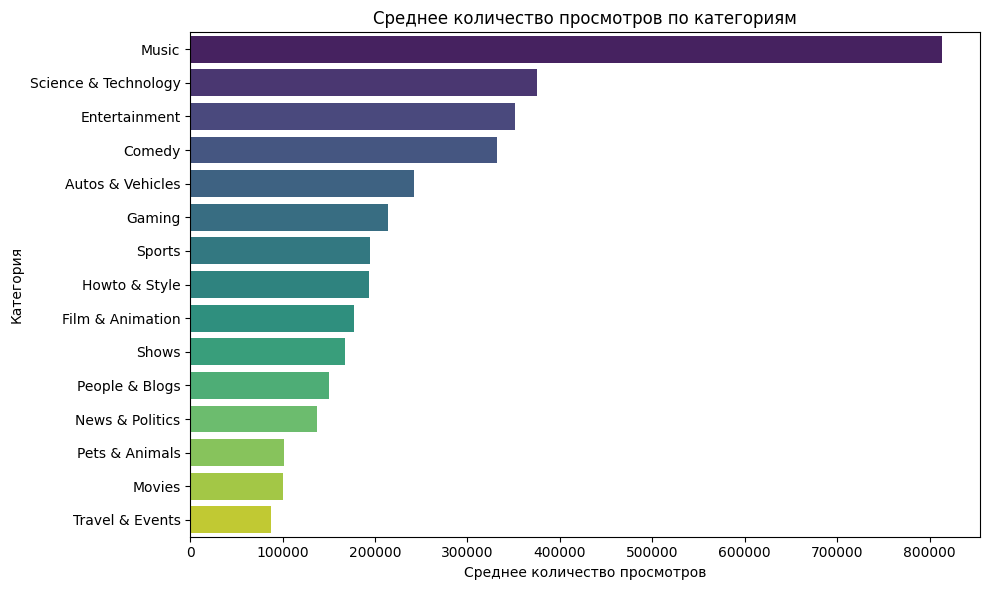

In [19]:
# топ-10 категорий по среднему числу просмотров
top_views = (
    df.groupby("category_name")["views"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=top_views,
    x="views",
    y="category_name",
    hue="category_name",   # ← теперь это столбец в DataFrame
    palette="viridis"
)
plt.title("Среднее количество просмотров по категориям")
plt.xlabel("Среднее количество просмотров")
plt.ylabel("Категория")
plt.tight_layout()
plt.show()

Топ 5 трендовых видео идут в категориях: Музыка, наука и технологии, развлечения, комедия, авто и транспорт

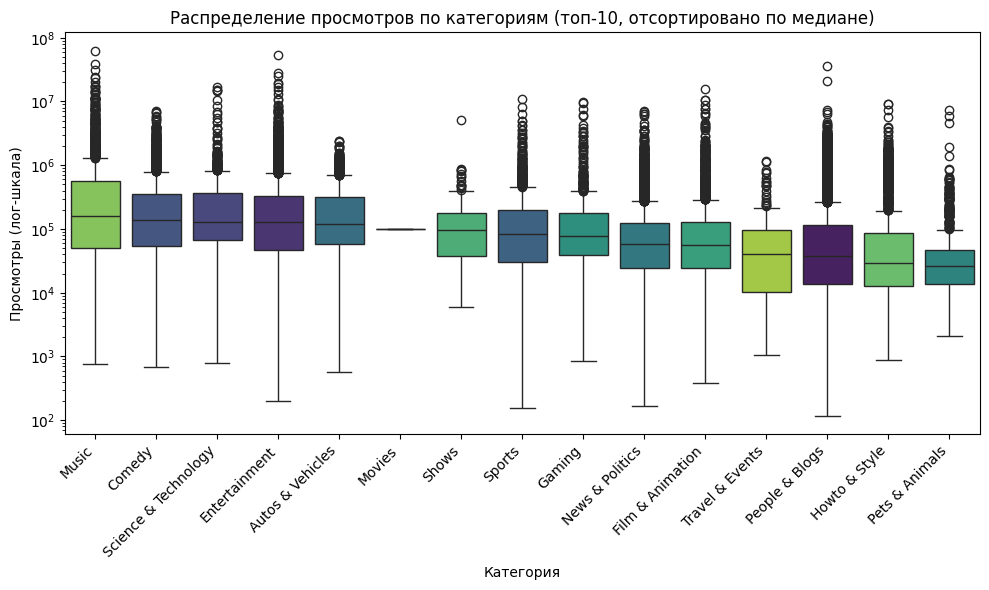

In [20]:

top_categories = top_views["category_name"].tolist()

median_order = (
    df[df["category_name"].isin(top_categories)]
    .groupby("category_name")["views"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()   # превращаем Index в обычный список
)

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df[df["category_name"].isin(top_categories)],
    x="category_name",
    y="views",
    hue="category_name",
    order=median_order,
    palette="viridis"
)
plt.yscale("log")
plt.title("Распределение просмотров по категориям (топ-10, отсортировано по медиане)")
plt.xlabel("Категория")
plt.ylabel("Просмотры (лог-шкала)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

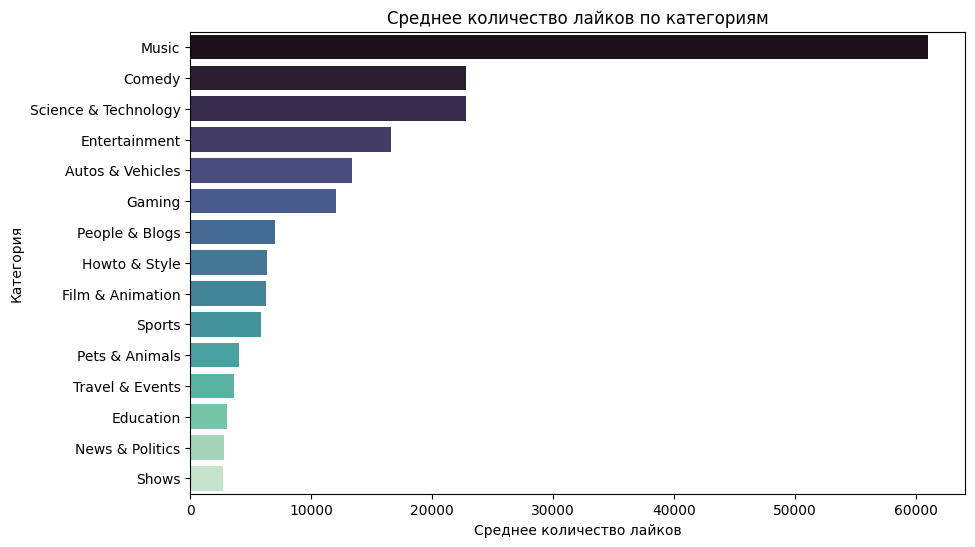

In [21]:
top_likes = (
    df.groupby("category_name")["likes"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

plt.figure(figsize=(10,6))
sns.barplot(data = top_likes, x=top_likes.likes, y=top_likes.category_name, hue="category_name", palette="mako")
plt.title("Среднее количество лайков по категориям")
plt.xlabel("Среднее количество лайков")
plt.ylabel("Категория")
plt.show()

Музыка лидирует по лайкам, comedy с 4 места по просмотрам выходит на второе по лайкам, люди особо охотно лайкают комедийный контент. Далее лидеры идут как в предыдущем графике.

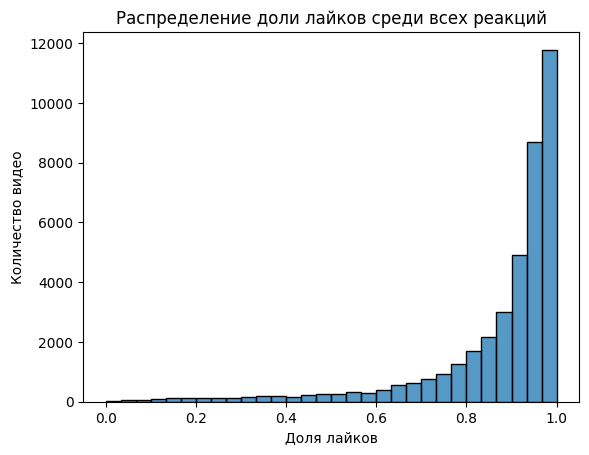

In [22]:
df["like_ratio"] = df["likes"] / (df["likes"] + df["dislikes"])
sns.histplot(df["like_ratio"].dropna(), bins=30)
plt.title("Распределение доли лайков среди всех реакций")
plt.xlabel("Доля лайков")
plt.ylabel("Количество видео")
plt.show()

Большее количество видео имеет долю лайков от 80 процентов, в целом по графику видно что люди больше ставят лайки на видео контент нежели дислайки, в целом большая часть контента воспринимается позитивно

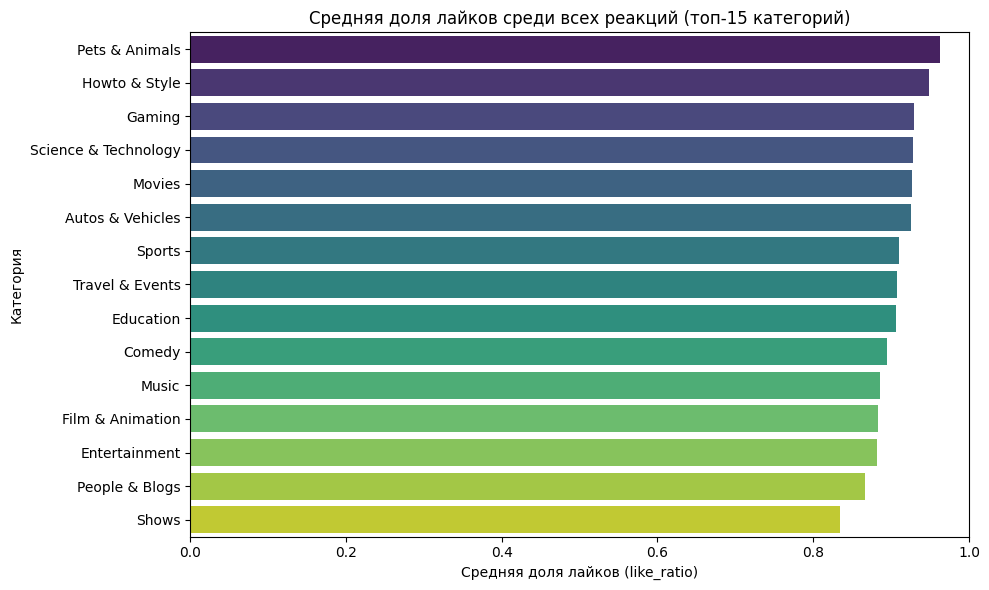

In [23]:
mean_like_ratio = (
    df.groupby("category_name")["like_ratio"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

# строим график
plt.figure(figsize=(10,6))
sns.barplot(
    data=mean_like_ratio,
    x="like_ratio",
    y="category_name",
    hue="category_name",
    palette="viridis",
    dodge=False,
    legend=False
)
plt.title("Средняя доля лайков среди всех реакций (топ-15 категорий)")
plt.xlabel("Средняя доля лайков (like_ratio)")
plt.ylabel("Категория")
plt.xlim(0, 1)  # ограничим ось X от 0 до 1
plt.tight_layout()
plt.show()

Самые "залайканые" видео это видео про милых животных, на втором месте "Мода и стиль", третье место - компьютерные игры. Четвертое место занимает жанр - топ 2 по просмотрам - Science&Technology. Лидер просмотров  - музыка, занимает 11 место по доле лайков, у исполнителей и коллективов много поклонников, но так же есть большие отряды "хейтеров".

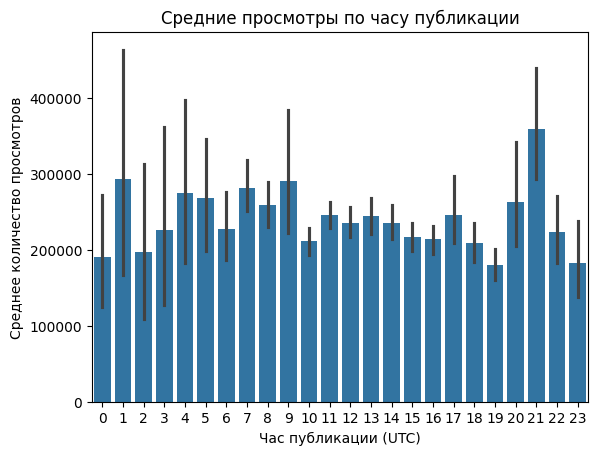

In [24]:
df["publish_time"] = pd.to_datetime(df["publish_time"], errors="coerce")
df["publish_hour"] = df["publish_time"].dt.hour

sns.barplot(x="publish_hour", y="views", data=df)
plt.title("Средние просмотры по часу публикации")
plt.xlabel("Час публикации (UTC)")
plt.ylabel("Среднее количество просмотров")
plt.show()

Самые высокие просмотры у видео которые выкладываются к 21-00. Далее идут 1 час ночи и 9 утра. Видео, выкладываемые в остальное время, имеют в среднем от 20 до 30 тысяч просмотров

In [25]:
top_channels = (
    df.groupby("channel_title")[["views", "likes"]]
    .mean()
    .sort_values(by="views", ascending=False)
    .head(30)
    .reset_index()
)
top_channels

,channel_title,views,likes
0,Kylie Jenner,2.837714e+07,0.000000e+00
1,YouTube Spotlight,2.584713e+07,1.017341e+06
2,FoxStarHindi,1.863920e+07,5.117880e+05
3,ibighit,1.759035e+07,2.117632e+06
4,Dharma Productions,1.596992e+07,3.083820e+05
5,TaylorSwiftVEVO,1.593954e+07,1.029428e+06
6,ChildishGambinoVEVO,1.545536e+07,7.721627e+05
7,KSI,1.506635e+07,4.049790e+05
8,Lil pump,1.455394e+07,1.038498e+06
9,DrakeVEVO,1.329426e+07,1.172000e+06


Топ три канала по просмотрам это: Kylie Jenner, YouTube Spotlight, FoxStarHindi. Любопытно у канала Kylie Jenner, нет информации по количеству лайков

In [26]:
df[df['channel_title'] == 'Kylie Jenner']

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,category_name,like_ratio,publish_hour
16231,BhIEIO0vaBE,2018-02-05,To Our Daughter,Kylie Jenner,22,2018-02-04 20:27:38+00:00,"Kylie Jenner|""Kylie""|""Travis Scott""|""Baby""|""An...",20921796,0,0,0,https://i.ytimg.com/vi/BhIEIO0vaBE/default.jpg,True,True,False,Directed by Tyler Ross @wttyler\nMusic by Jaco...,People & Blogs,NaN,20
16449,BhIEIO0vaBE,2018-02-06,To Our Daughter,Kylie Jenner,22,2018-02-04 20:27:38+00:00,"Kylie Jenner|""Kylie""|""Travis Scott""|""Baby""|""An...",35832484,0,0,0,https://i.ytimg.com/vi/BhIEIO0vaBE/default.jpg,True,True,False,Directed by Tyler Ross @wttyler\nMusic by Jaco...,People & Blogs,NaN,20


Топ канал из нашего списка два дня попадал в тренды и набрал в среднем 28 млн просмотров в день

Все топ 30 каналов не русскоязычные, хочется посмотреть топ именно русскоязычных каналов. 

In [27]:
def has_cyrillic(text):
    if isinstance(text, str):
        return bool(re.search(r'[А-Яа-яЁё]', text))
    return False

In [28]:
# проверяем есть ли русские буквы в описании
df["is_russian"] = df["description"].apply(has_cyrillic)

df_ru = df[df["is_russian"] == True].copy()

print(f"Всего русскоязычных видео: {len(df_ru)} из {len(df)}")

Всего русскоязычных видео: 34990 из 40693


In [29]:
russian_channels = (
    df_ru.groupby("channel_title")[["views"]]
    .mean()
    .sort_values("views", ascending=False)
    .reset_index()
)

print(russian_channels.head(30))

                channel_title         views
0                Comedy Radio  4.760212e+06
1              World Cup Free  3.841044e+06
2                     ВОТ ТАК  3.741222e+06
3              Семен Слепаков  3.691060e+06
4                      Тимати  3.164704e+06
5       Ленинград | Leningrad  3.067088e+06
6                  SlivkiShow  2.677723e+06
7                 BadComedian  2.658326e+06
8                     StarPro  2.423947e+06
9                 Познаватель  2.418017e+06
10                  PewDiePie  2.393463e+06
11              Євген Лущиков  2.361401e+06
12           PressTube Russia  2.336368e+06
13                      вДудь  2.314236e+06
14                       FACE  2.165072e+06
15                     Broksh  2.152671e+06
16                    SOBOLEV  2.122996e+06
17           Интересный Канал  2.105048e+06
18              MARVEL Россия  2.023811e+06
19                 Jah Khalib  1.961722e+06
20                      7Дней  1.913682e+06
21                  Kluna Tik  1

Топ три русскоязычных канала по просмотрам: Comedy Radio, World Cup Free, ВОТ ТАК

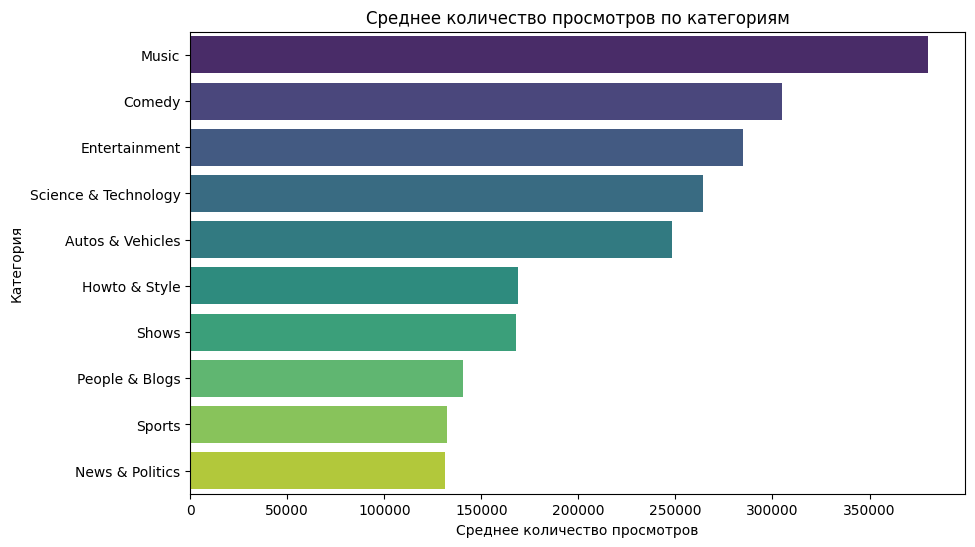

In [30]:
# Топ-10 категорий по среднему числу просмотров
top_views = (
    df_ru.groupby("category_name")["views"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10,6))
sns.barplot(data=top_views, x="views", y="category_name", hue="category_name", palette="viridis")
plt.title("Среднее количество просмотров по категориям")
plt.xlabel("Среднее количество просмотров")
plt.ylabel("Категория")
plt.show()

Топ 5 тот же что и с учетом англоязычных каналов, но позиции некоторых категорий не совпадают. Comedy и entertainment, занимают второе и третье место.

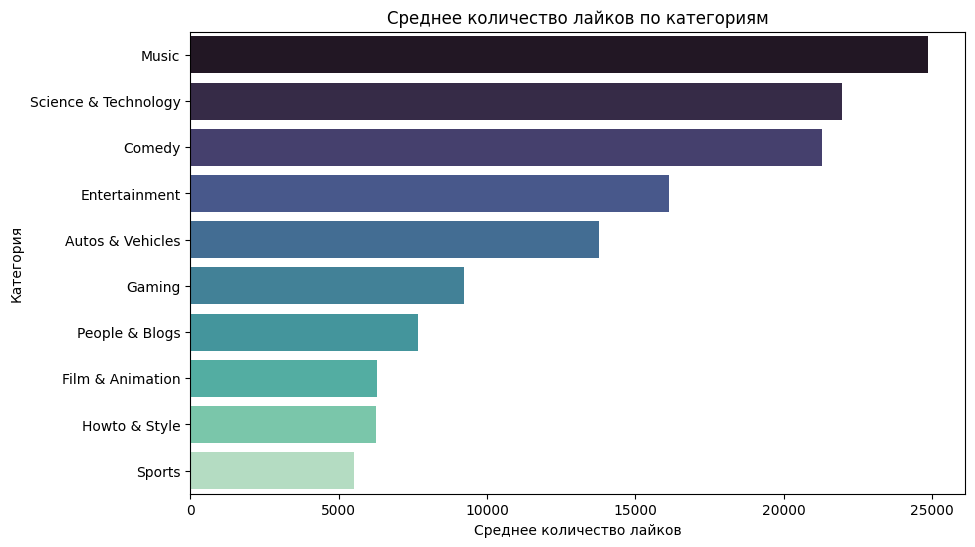

In [31]:
top_likes = (
    df_ru.groupby("category_name")["likes"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10,6))
sns.barplot(data=top_likes, x="likes", y="category_name", hue="category_name", palette="mako")
plt.title("Среднее количество лайков по категориям")
plt.xlabel("Среднее количество лайков")
plt.ylabel("Категория")
plt.show()

Те же топ 5 что и с англоязычными кналами, но чаще лайкают науно-популярные видео чем comedy

In [32]:
# выбираем наборы параметров для корреляции по phik
cols_for_phik = [
    "views", "likes", "dislikes", "comment_count",
    "like_ratio", "publish_hour", "category_name", "is_russian"
]

# фильтруем только нужные столбцы и убираем NaN
df_phik = df_ru[cols_for_phik].dropna().copy()


In [33]:
phik_matrix = df_phik.phik_matrix(interval_cols=["views", "likes", "dislikes", "comment_count", "like_ratio", "publish_hour"])


C:\Users\Станция\AppData\Local\Programs\Python\Python312\Lib\site-packages\phik\data_quality.py:82: UserWarning: Not enough unique value for variable is_russian for analysis 1. Dropping this column
  warnings.warn(


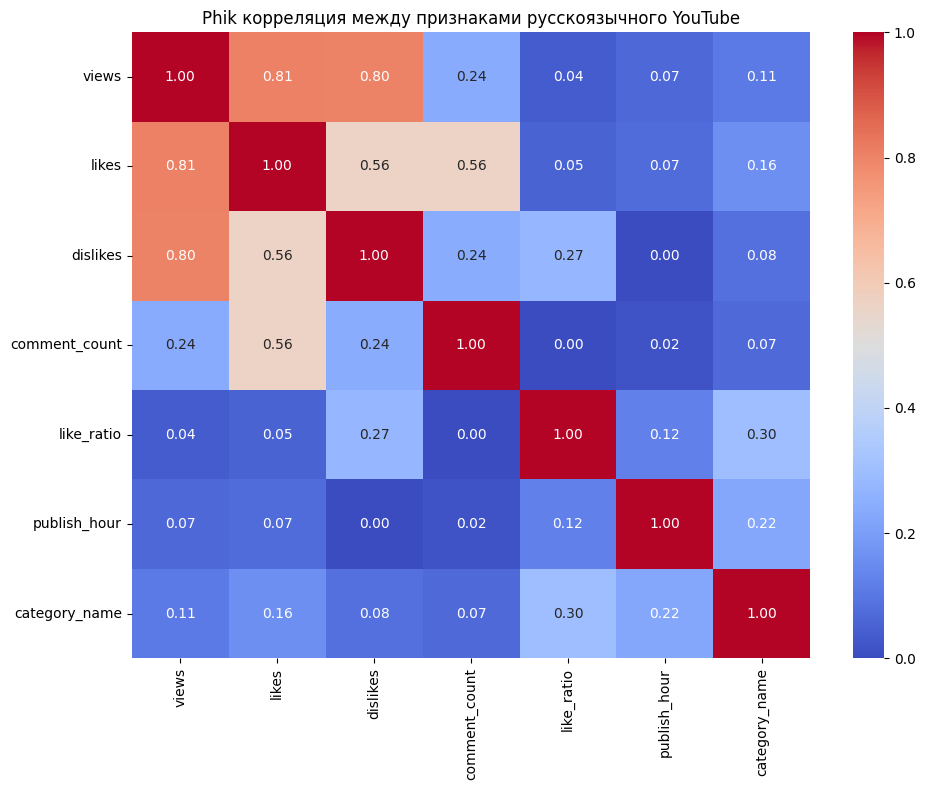

In [34]:
plt.figure(figsize=(10,8))
sns.heatmap(phik_matrix, cmap='coolwarm', annot=True, fmt=".2f", vmin=0, vmax=1)
plt.title("Phik корреляция между признаками русскоязычного YouTube")
plt.tight_layout()
plt.show()

Сильная связь между просмотрами и лайками. Так же между просмотрами и дислайками, чем больше дислайков тем больше просмотров, как бы это странно не звучало. Есть определенные пропорции лайков к дислайкам, чем больше лайков тем, соответственно, больше и дислайков. Так же чем больше лайков тем лучше продвигается видео.

Парные зависимости на графике, для проверки и подверждения корреляции.

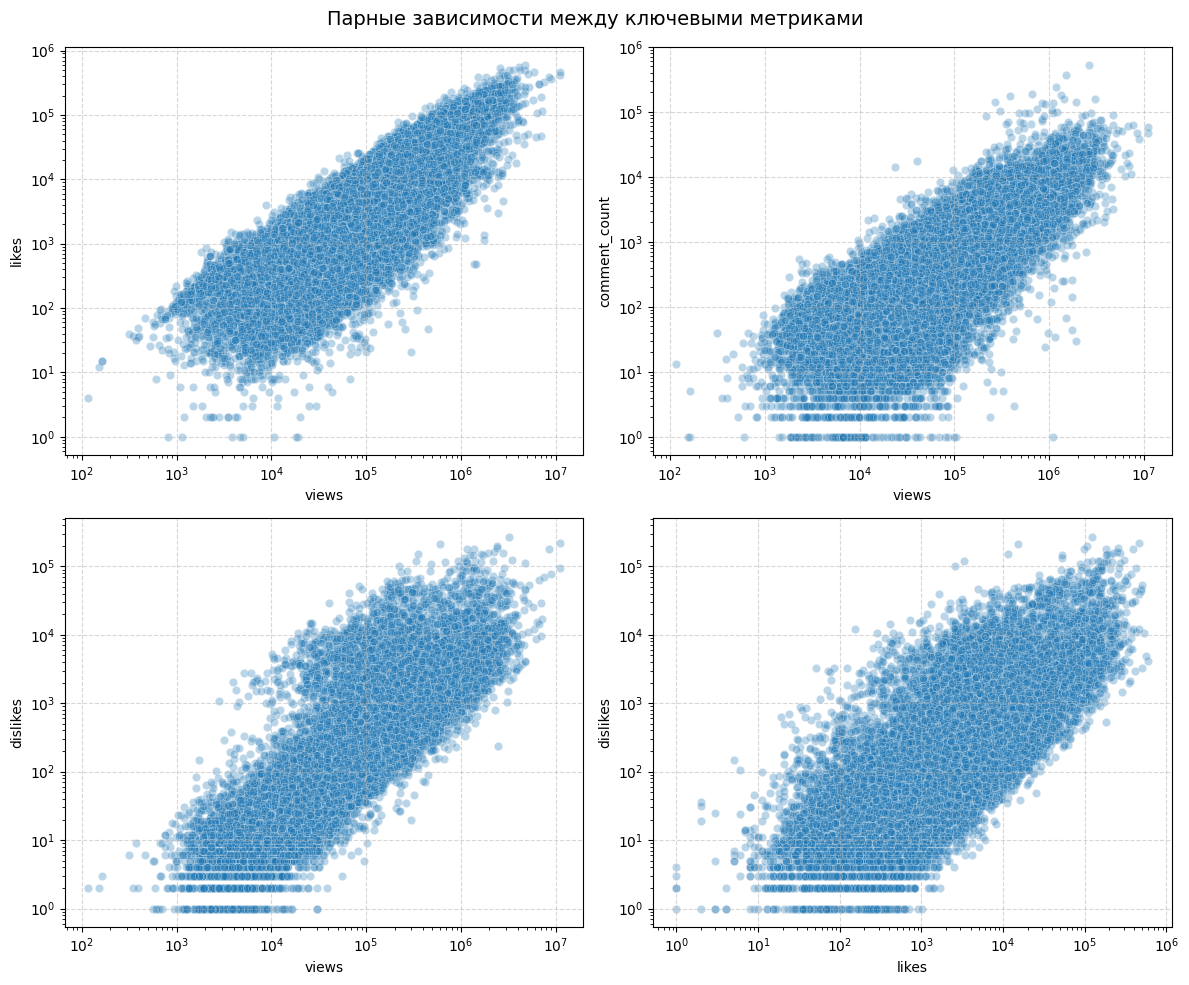

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(12,10))

sns.scatterplot(data=df_ru, x="views", y="likes", ax=axes[0,0], alpha=0.3)
sns.scatterplot(data=df_ru, x="views", y="comment_count", ax=axes[0,1], alpha=0.3)
sns.scatterplot(data=df_ru, x="views", y="dislikes", ax=axes[1,0], alpha=0.3)
sns.scatterplot(data=df_ru, x="likes", y="dislikes", ax=axes[1,1], alpha=0.3)

for ax in axes.flat:
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(True, linestyle="--", alpha=0.5)

plt.suptitle("Парные зависимости между ключевыми метриками", fontsize=14)
plt.tight_layout()
plt.show()

Линейная связь подтверждается, между лайками и просмотрами самое узкое облако разбросанных значений, и имеет близкий к 45 градусам наклон. Сильная зависимость видна и на графике. Умеренная связь между лайками и дислайками видна и на графике рассеивания, хотя  само облако более широкое и наклон дальше от идеальных 45 градусов чем левая-верхняя картинка.

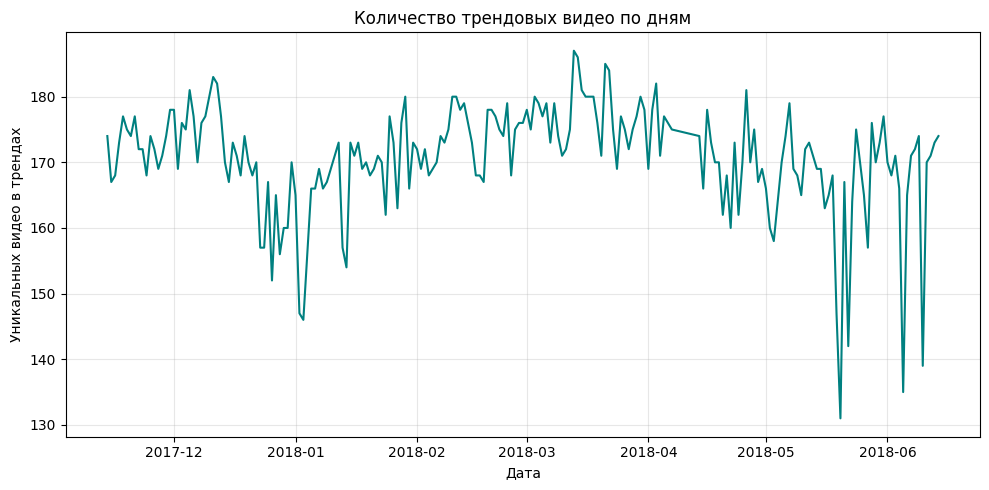

Среднее количество видео в день: 170.7
Минимум: 131 | Максимум: 187


In [36]:
# сколько уникальных видео было в трендах каждый день
daily_trend_count = df_ru.groupby('trending_date')['video_id'].nunique().reset_index(name='videos_in_trend')

plt.figure(figsize=(10,5))
sns.lineplot(data=daily_trend_count, x='trending_date', y='videos_in_trend', color='teal')
plt.title('Количество трендовых видео по дням')
plt.xlabel('Дата')
plt.ylabel('Уникальных видео в трендах')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Среднее количество видео в день: {daily_trend_count['videos_in_trend'].mean():.1f}")
print(f"Минимум: {daily_trend_count['videos_in_trend'].min()} | Максимум: {daily_trend_count['videos_in_trend'].max()}")

Пик трендовых видео был в середине марта 2018, самый низкий уровень был в середине мая 2018г. Среднее количество тредовых видео находится в районе 170 в день.

📊 Средние показатели по дням в тренде:
count    29753.000000
mean         1.175881
std          0.421293
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          4.000000
Name: days_in_trend, dtype: float64


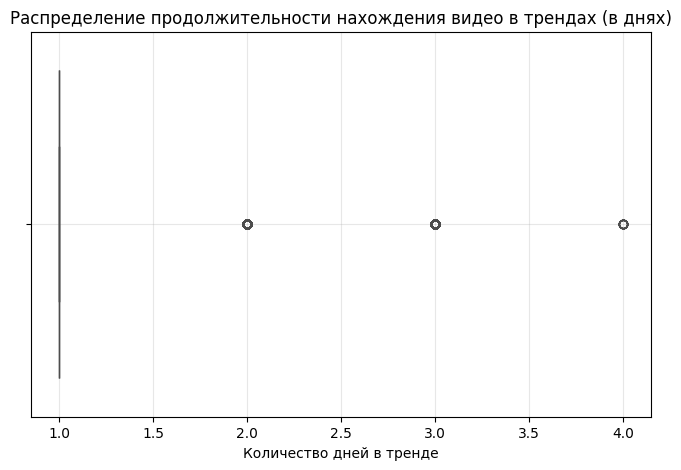

Среднее: 1.2 дней
Медиана: 1.0
Максимум: 4 дней


In [37]:
# считаем уникальные даты тренда на одно видео
trend_days = df_ru.groupby('video_id')['trending_date'].nunique().reset_index(name='days_in_trend')

print("📊 Средние показатели по дням в тренде:")
print(trend_days['days_in_trend'].describe())

plt.figure(figsize=(8,5))
sns.boxplot(x=trend_days['days_in_trend'], color='orange')
plt.title('Распределение продолжительности нахождения видео в трендах (в днях)')
plt.xlabel('Количество дней в тренде')
plt.grid(alpha=0.3)
plt.show()

print(f"Среднее: {trend_days['days_in_trend'].mean():.1f} дней")
print(f"Медиана: {trend_days['days_in_trend'].median():.1f}")
print(f"Максимум: {trend_days['days_in_trend'].max()} дней")

Среднее и медианное время нахождения видео в трендах 1 день. Максимально одно видео пробыло в трендах 4 дня.

In [38]:
# получаем id этого видео
top_video_id = trend_days.loc[trend_days['days_in_trend'] == trend_days['days_in_trend'].max(), 'video_id'].values[0]

# извлекаем всю информацию о нём
top_video_info = df_ru[df_ru['video_id'] == top_video_id]

top_video_info

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,category_name,like_ratio,publish_hour,is_russian
37804,1nX0kF2UwDc,2018-05-31,[BadComedian] - Движение Вверх (Плагиат или ве...,BadComedian,23,2018-05-30 18:20:48+00:00,"BadComedian|""Евген""|""Bad""|""Comedian""|""Фильмы""|...",3125598,334685,7777,34556,https://i.ytimg.com/vi/1nX0kF2UwDc/default.jpg,False,False,False,"#BadComedian обзор фильма Движение Вверх, кото...",Comedy,0.977291,18,True
38004,1nX0kF2UwDc,2018-06-01,[BadComedian] - Движение Вверх (Плагиат или ве...,BadComedian,23,2018-05-30 18:20:48+00:00,"BadComedian|""Евген""|""Bad""|""Comedian""|""Фильмы""|...",3932918,369380,9070,39265,https://i.ytimg.com/vi/1nX0kF2UwDc/default.jpg,False,False,False,"#BadComedian обзор фильма Движение Вверх, кото...",Comedy,0.976034,18,True
38217,1nX0kF2UwDc,2018-06-02,[BadComedian] - Движение Вверх (Плагиат или ве...,BadComedian,23,2018-05-30 18:20:48+00:00,"BadComedian|""Евген""|""Bad""|""Comedian""|""Фильмы""|...",5070679,429339,11139,46666,https://i.ytimg.com/vi/1nX0kF2UwDc/default.jpg,False,False,False,"#BadComedian обзор фильма Движение Вверх, кото...",Comedy,0.974712,18,True
38525,1nX0kF2UwDc,2018-06-03,[BadComedian] - Движение Вверх (Плагиат или ве...,BadComedian,23,2018-05-30 18:20:48+00:00,"BadComedian|""Евген""|""Bad""|""Comedian""|""Фильмы""|...",5848428,465669,12158,50943,https://i.ytimg.com/vi/1nX0kF2UwDc/default.jpg,False,False,False,"#BadComedian обзор фильма Движение Вверх, кото...",Comedy,0.974556,18,True


Это видео BadComedian, жанр comedy, обзор кинофильмов.

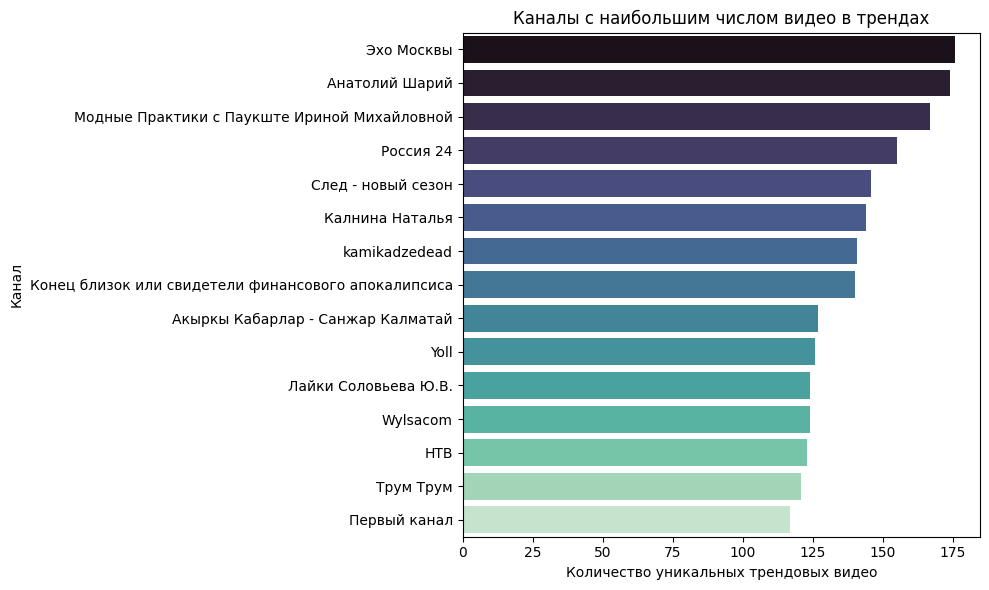

,channel_title,trending_videos
0,Эхо Москвы,176
1,Анатолий Шарий,174
2,Модные Практики с Паукште Ириной Михайловной,167
3,Россия 24,155
4,След - новый сезон,146
5,Калнина Наталья,144
6,kamikadzedead,141
7,Конец близок или свидетели финансового апокали...,140
8,Акыркы Кабарлар - Санжар Калматай,127
9,Yoll,126


In [39]:
channel_trend_count = (
    df_ru.groupby('channel_title')['video_id']
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name='trending_videos')
)

top_channels_count = channel_trend_count.head(15)

plt.figure(figsize=(10,6))
sns.barplot(data=top_channels_count, x='trending_videos', y='channel_title', hue='channel_title', palette='mako')
plt.title('Каналы с наибольшим числом видео в трендах')
plt.xlabel('Количество уникальных трендовых видео')
plt.ylabel('Канал')
plt.tight_layout()
plt.show()

top_channels_count.head(10)


Топ три канала-генератора трендовых видео это Эхо Москвы, Анатолий Шарий и Модные Практики с Паукште Ириной Михайловной. 

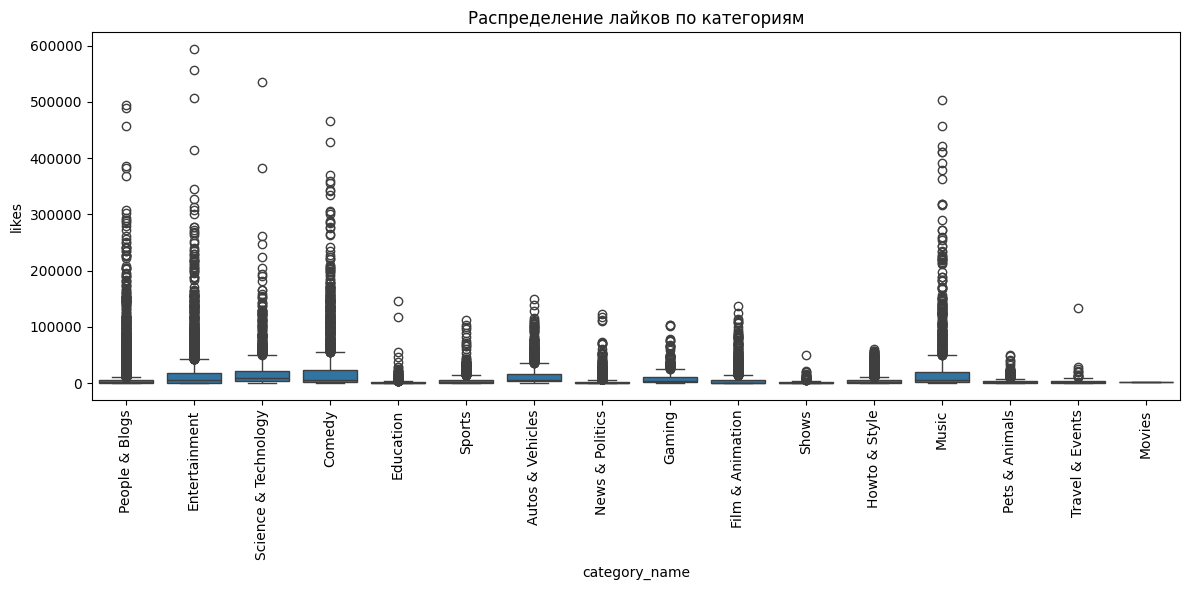

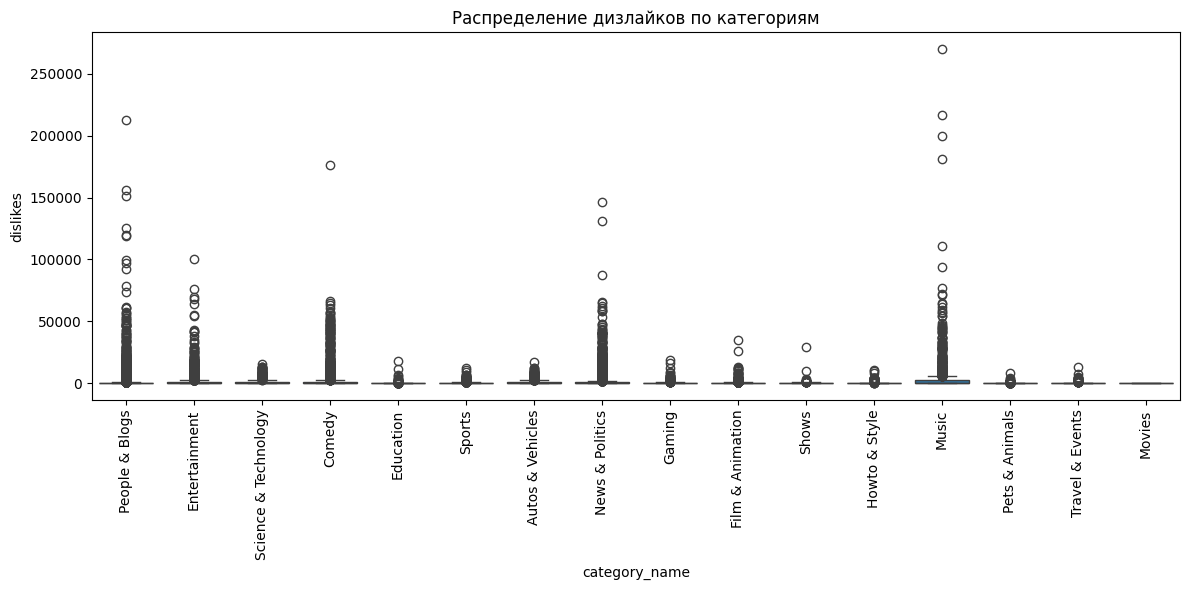

In [40]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_ru, x='category_name', y='likes')
plt.xticks(rotation=90)
plt.title('Распределение лайков по категориям')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
sns.boxplot(data=df_ru, x='category_name', y='dislikes')
plt.xticks(rotation=90)
plt.title('Распределение дизлайков по категориям')
plt.tight_layout()
plt.show()

Без логарифмической шкалы данные выглядят плохо и непонятно, нужно добавить лог. шкалу, заодно отсортируем данные по медиане

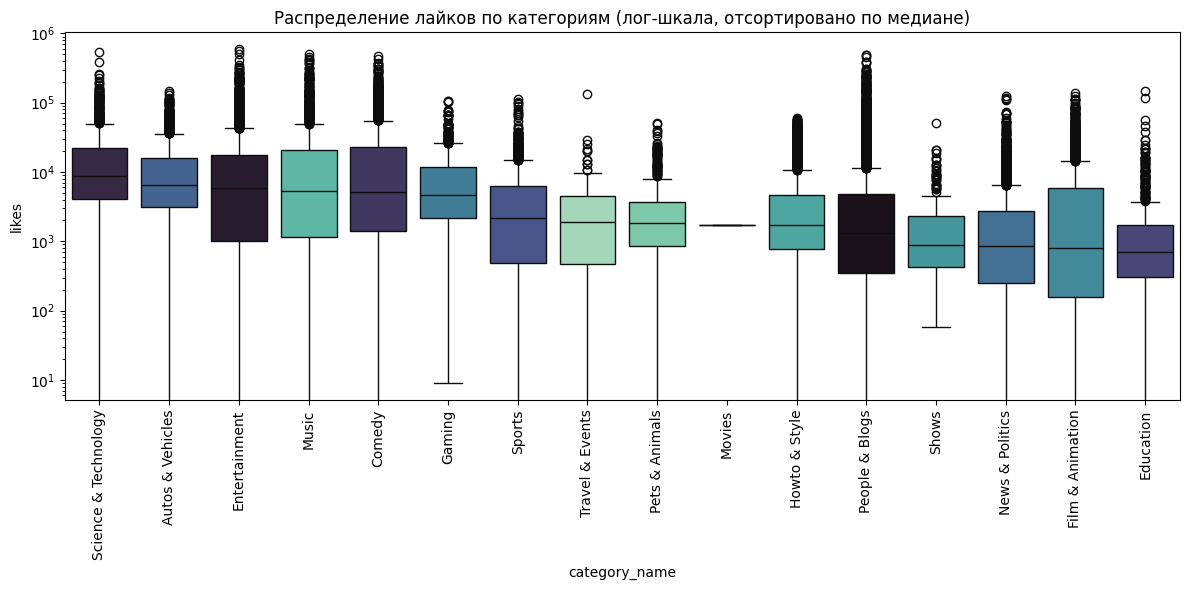

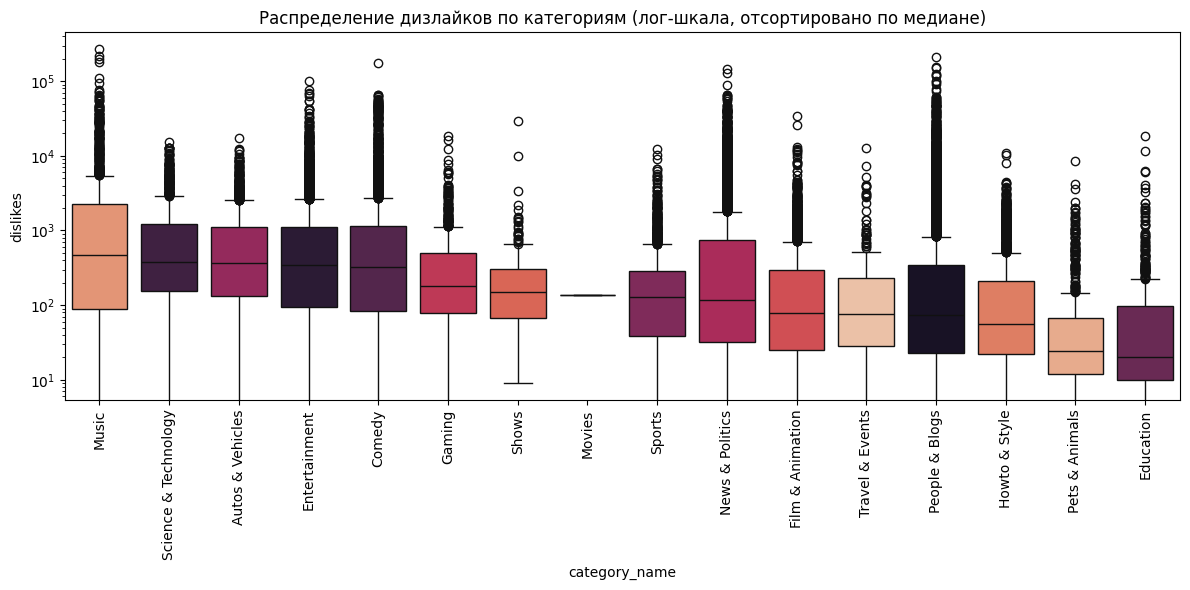

In [41]:
# Сортировка категорий по медиане лайков 
order_likes = (
    df_ru.groupby("category_name")["likes"]
    .median()
    .sort_values(ascending=False)
    .index
)


plt.figure(figsize=(12,6))
sns.boxplot(
    data=df_ru,
    x="category_name",
    y="likes",
    order=order_likes,
    hue="category_name",     
    palette="mako",
    legend=False
)
plt.yscale("log")
plt.xticks(rotation=90)
plt.title("Распределение лайков по категориям (лог-шкала, отсортировано по медиане)")
plt.tight_layout()
plt.show()


# Сортировка категорий по медиане дизлайков
order_dislikes = (
    df_ru.groupby("category_name")["dislikes"]
    .median()
    .sort_values(ascending=False)
    .index
)


plt.figure(figsize=(12,6))
sns.boxplot(
    data=df_ru,
    x="category_name",
    y="dislikes",
    order=order_dislikes,
    hue="category_name",
    palette="rocket",
    legend=False
)
plt.yscale("log")
plt.xticks(rotation=90)
plt.title("Распределение дизлайков по категориям (лог-шкала, отсортировано по медиане)")
plt.tight_layout()
plt.show()

Видим трех лидеров по медианным лайкам: Science&Tecnology, Autos&Vehicles, Entertainment
Три лидера по медианным дислайкам: Music, Science&Tecnology, Autos&Vehicles. 
Есть интересный момент, катагория Movies, показывет самый низкий разброс данных, самые стабильные данные. Либо по этой категории очень мало наблюдений?

In [42]:
category_counts = (
    df_ru["category_name"]
    .value_counts()
    .reset_index()
)

category_counts

,category_name,count
0,People & Blogs,8583
1,Entertainment,5084
2,News & Politics,4652
3,Comedy,2878
4,Film & Animation,2355
5,Howto & Style,1911
6,Sports,1630
7,Autos & Vehicles,1539
8,Music,1412
9,Science & Technology,1051


Только одно видео категории Movies представленно, этим объясняется "низкий разброс" данных

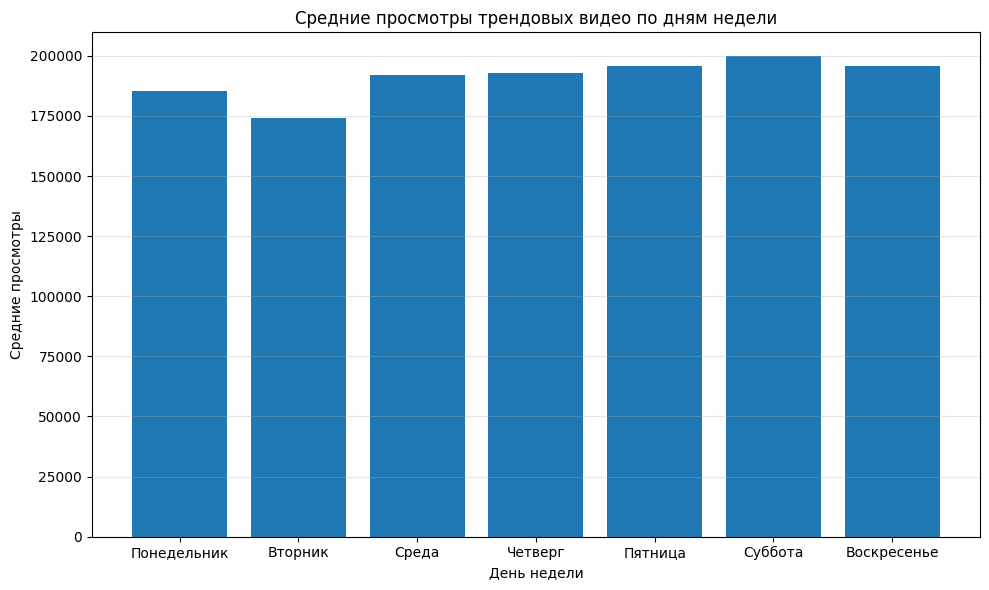

C:\Users\Станция\AppData\Local\Temp\ipykernel_16476\3201113948.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(groups, labels=[map_rus[w] for w in order], showfliers=False)


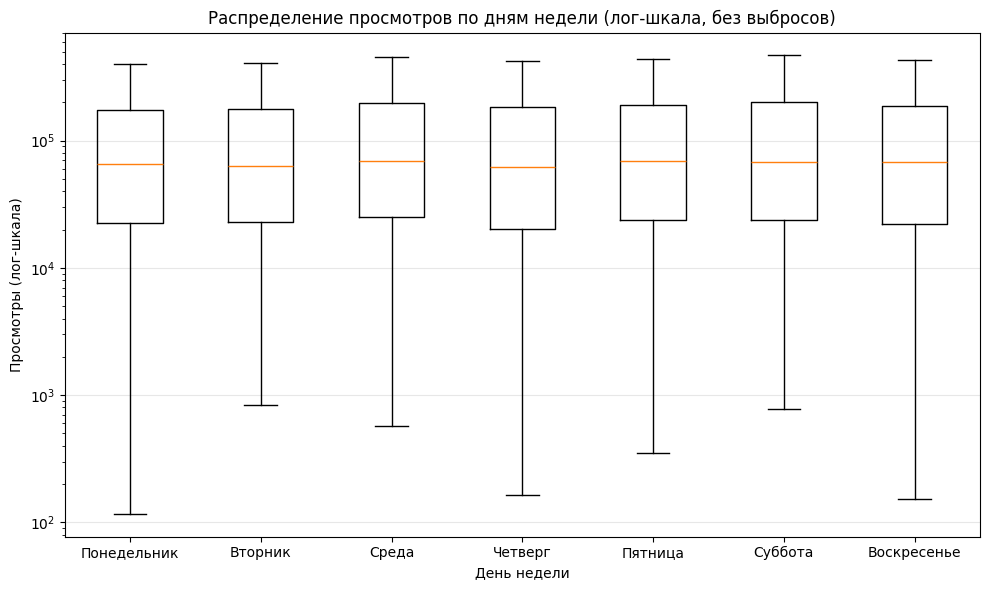

In [43]:
# День недели: число (0=Mon … 6=Sun) и удобная подпись
df_ru['weekday_num'] = df_ru['trending_date'].dt.weekday
eng_days = list(calendar.day_name)  # ['Monday', ..., 'Sunday']
rus_days = ['Понедельник','Вторник','Среда','Четверг','Пятница','Суббота','Воскресенье']
map_rus = dict(zip(range(7), rus_days))
df_ru['weekday'] = df_ru['weekday_num'].map(map_rus)

#  Агрегаты: средние просмотры и количество видео по дням недели
order = list(range(7))  # порядок Пн→Вс
views_by_weekday = (
    df_ru.groupby('weekday_num', as_index=False)
         .agg(mean_views=('views','mean'),
              count_videos=('video_id','nunique'))
         .sort_values('weekday_num')
)
views_by_weekday['weekday'] = views_by_weekday['weekday_num'].map(map_rus)

#  ГРАФИК 1: Средние просмотры по дням недели 
plt.figure(figsize=(10,6))
plt.bar(views_by_weekday['weekday'], views_by_weekday['mean_views'])
plt.title('Средние просмотры трендовых видео по дням недели')
plt.xlabel('День недели')
plt.ylabel('Средние просмотры')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


#  ГРАФИК 2: Boxplot просмотров по дням недели (лог-шкала) 
groups = [df_ru.loc[df_ru['weekday_num']==w, 'views'].values for w in order]

plt.figure(figsize=(10,6))
bp = plt.boxplot(groups, labels=[map_rus[w] for w in order], showfliers=False)  
plt.yscale('log')  
plt.title('Распределение просмотров по дням недели (лог-шкала, без выбросов)')
plt.xlabel('День недели')
plt.ylabel('Просмотры (лог-шкала)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Средние просмотры по дням недели сильно не отличаются. Средние просмотры в пятницу, субботу и воскресенье, выглядят выше чем остальные дни, но не намного. Самый низкий уровень средних просмотров во вторник, так же во вторник самый низкий разброс значений.

Проверим несколько гипотез на базе нашего датасета.
Первая гипотеза о равенстве/различии просмотров в выходные и будни
Вторая гипотеза о равенстве/различии промотров между топ жанром Music и остальными жанрами

In [44]:
# отделим выходной день от буднего
df_ru['is_weekend'] = df_ru['trending_date'].dt.weekday >= 5

# разделим на 2 выборки
weekend_views = df_ru.loc[df_ru['is_weekend'], 'views']
weekday_views = df_ru.loc[~df_ru['is_weekend'], 'views']

# логарифмируем, чтобы убрать сильный перекос
weekend_log = np.log1p(weekend_views)
weekday_log = np.log1p(weekday_views)

In [45]:
# Тест Шапиро-Уилка для нормальности
print("Shapiro weekday:", stats.shapiro(weekday_log.sample(5000)))
print("Shapiro weekend:", stats.shapiro(weekend_log.sample(5000)))

Shapiro weekday: ShapiroResult(statistic=np.float64(0.9985725800983934), pvalue=np.float64(0.00019323724477742963))
Shapiro weekend: ShapiroResult(statistic=np.float64(0.9977836761141285), pvalue=np.float64(1.2780444997429398e-06))


In [46]:
# Тест Манна–Уитни (альтернатива: у Music просмотров больше)
u_stat, p_value = stats.mannwhitneyu(weekend_views, weekday_views, alternative='two-sided')

print(f"p-value = {p_value:.6f}")

if p_value < 0.05:
    print("Отвергаем H0")
else:
    print("Различия по просмотрам между Weekend и рабочими нями недели статистически незначимы.")

p-value = 0.145972
Различия по просмотрам между Weekend и рабочими нями недели статистически незначимы.


In [47]:
# Выделяем просмотры для категории Music и для остальных
music_views = df_ru.loc[df_ru['category_name'] == 'Music', 'views']
other_views = df_ru.loc[df_ru['category_name'] != 'Music', 'views']

# Тест Шапиро-Уилка для нормальности
print("Shapiro music:", stats.shapiro(music_views.sample(1400)))
print("Shapiro other:", stats.shapiro(other_views.sample(1400)))

Shapiro music: ShapiroResult(statistic=np.float64(0.4413255865600898), pvalue=np.float64(2.0679841926764297e-54))
Shapiro other: ShapiroResult(statistic=np.float64(0.5083556505177399), pvalue=np.float64(2.884003270802655e-52))


Очень низкий p-value показывает тест Шапиро-Уилка, значит распределения не нормальны. Будем использовать тест Манна-Уитни

H0: Средние просмотры в категории Music не отличаются от других категорий.

H1: Средние просмотры в Music выше.

In [48]:
# Тест Манна–Уитни (альтернатива: у Music просмотров больше)
u_stat, p_value = stats.mannwhitneyu(music_views, other_views, alternative='greater')

print(f"p-value = {p_value:.100f}")

if p_value < 0.05:
    print("Отвергаем H0: у категории 'Music' просмотров больше, чем у остальных.")
else:
    print("Различия по просмотрам между 'Music' и другими категориями статистически незначимы.")

p-value = 0.0000000000000000000000000000000000000000000000000000000007503457806093104799730226296321512233342990
Отвергаем H0: у категории 'Music' просмотров больше, чем у остальных.


Проверим гипотезу о том что чем больше тегов - тем больше просмотров.
Н0 - просмотры у видео с небольшим и с большим количеством тегов равны
Н1 - больше просмотров у видео с большим количеством тегов

In [49]:
# Сосчитаем теги
def tag_count(s):
    if not isinstance(s, str) or s.strip()=='' or s.strip().lower()=='[none]':
        return 0
    # теги в датасете разделены символом '|'
    return s.count('|') + 1

df_work = df_ru.copy()
df_work['tags_count'] = df_work['tags'].apply(tag_count)

print(df_work['tags_count'].describe())
print("Пример распределения:\n", df_work['tags_count'].value_counts().sort_index().head(20))

count    34990.000000
mean        18.300514
std         12.692393
min          0.000000
25%          9.000000
50%         17.000000
75%         26.000000
max         76.000000
Name: tags_count, dtype: float64
Пример распределения:
 tags_count
0     2402
1      698
2      437
3      552
4      749
5      834
6     1058
7      965
8      871
9     1018
10    1092
11    1040
12    1064
13    1050
14    1069
15     994
16    1178
17     968
18     906
19     999
Name: count, dtype: int64


Для начала применим корреляцию Спирмена (данные будут не нормально распределены, много одинаковых значений)

In [50]:
#корреляция Спирмена (монотонная связь tags_count ~ views) ===
mask = df_work['views'].notna() & df_work['tags_count'].notna()
rho, p = stats.spearmanr(df_work.loc[mask, 'tags_count'], df_work.loc[mask, 'views'])
if p < 0.05:
    print(f"Spearman rho = {rho:.3f}, p-value = {p:.3g}, Нулевая гипотеза отвергается")
else:
    print(f"Spearman rho = {rho:.3f}, p-value = {p:.3g}, Нулевая гипотеза не может быть отвергнута")

Spearman rho = 0.099, p-value = 4.89e-77, Нулевая гипотеза отвергается


p-value=1.2e-32, Количество наблюдений low=18039, Количество наблюдений high=16951, Нулевая гипотеза отвергается


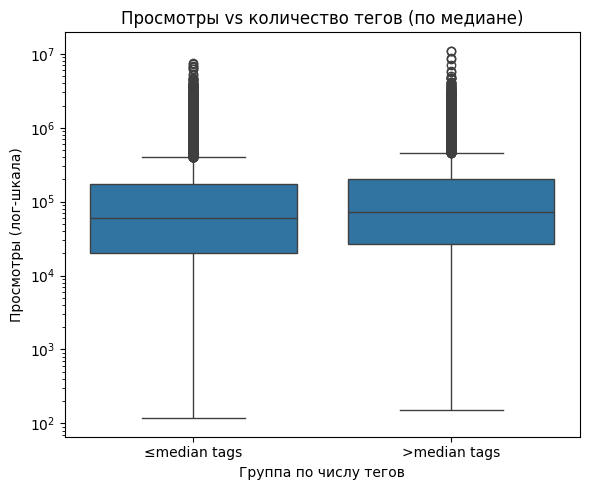

In [51]:
# Манн–Уитни: много тегов vs мало ===
# делим порог по медиане числа тегов, чтобы получить две группы схожего размера
medi_tags = df_work['tags_count'].median()
low  = df_work.loc[df_work['tags_count'] <=  medi_tags, 'views']
high = df_work.loc[df_work['tags_count'] >   medi_tags, 'views']

u, p = stats.mannwhitneyu(high, low, alternative='greater')  # H1: у "много тегов" просмотров больше
if p < 0.05:
    print(f"p-value={p:.3g}, Количество наблюдений low={len(low)}, Количество наблюдений high={len(high)}, Нулевая гипотеза отвергается")
else:
    print(f"p-value={p:.3g}, Количество наблюдений low={len(low)}, Количество наблюдений high={len(high)}, Нулевая гипотеза не может быть отвергнута")

#визуализация: бокс-плот в лог-шкале
plt.figure(figsize=(6,5))
sns.boxplot(data=pd.DataFrame({'views': pd.concat([low, high], ignore_index=True),
                               'group': ['≤median tags']*len(low)+['>median tags']*len(high)}),
            x='group', y='views')
plt.yscale('log')
plt.title('Просмотры vs количество тегов (по медиане)')
plt.xlabel('Группа по числу тегов')
plt.ylabel('Просмотры (лог-шкала)')
plt.tight_layout()
plt.show()

Статистические тесты и boxplot показывают нам небольшое, но все же статистически значимое превышение просмотров у видео с количеством тегов больше медианного.

<h1>Итоги проекта YouTube Trending </h1>

<h2>Данные и период</h2>
<p>
Проанализирован датасет <b>трендов YouTube Russia</b> за <b>14.11.2017 — 14.06.2018</b> (~40 тыс. строк после очистки).<br>
Категории расшифрованы из JSON; приведены даты/времена, обработаны дубликаты и технические артефакты (<code>#NAME?</code>), 
добавлены производные признаки (час публикации, like-ratio, фильтр русскоязычных видео и т. п.).
</p>

<h2>Характер данных</h2>
<p>
Распределения метрик <b>сильно перекошены</b> (длинные хвосты), поэтому для корректного анализа использовались 
<b>логарифмическая шкала</b> и <b>непараметрические тесты</b>.
</p>

<h2>Корреляции</h2>
<ul>
<li>Наблюдается <b>сильная положительная связь</b> <code>views ↔ likes</code> и <b>умеренная</b> <code>views ↔ comment_count</code> — чем выше охват, тем выше вовлечённость.</li>
<li>Корреляции с категориями присутствуют, но выражены слабее.</li>
</ul>

<h2>Категории</h2>
<ul>
<li><b>Music</b> — уверенный лидер по просмотрам (и по средним, и по медианам).</li>
<li><b>Entertainment</b> и <b>Comedy</b> — следующий эшелон.</li>
<li><b>Science & Technology</b> — стабильные средние показатели.</li>
<li><b>Howto & Style / People & Blogs / Travel & Events / Sports</b> — существенно ниже по охватам.</li>
</ul>

<p><b>Статистически подтверждено (Mann–Whitney):</b> у категории <b>Music</b> просмотров <b>значимо больше</b>, чем у остальных.</p>

<h2>Время и календарь</h2>
<ul>
<li>Эффект <b>дня недели</b> статистически незначим (<code>p ≈ 0.14</code>). Наблюдаемый косметический рост к выходным не подтверждён тестом.</li>
<li><b>Час публикации</b> в факторной модели — пограничный/незначимый.</li>
</ul>

<h2>Теги</h2>
<ul>
<li>Есть <b>слабая, но стабильная положительная связь</b> между количеством тегов и просмотрами.</li>
<li>По тесту <b>Манна–Уитни</b> у видео с числом тегов <b>выше медианы просмотры статистически выше</b>.</li>
<li><b>Вывод:</b> теги помогают как <b>тонкая настройка</b>, а не как основной драйвер охватов.</li>
</ul>

<h2>Ограничения</h2>
<ul>
<li>Данные только по <b>трендовым</b> видео (selection bias).</li>
<li>Период ограничен <b>2017–2018</b> годами, регион <b>RU</b>.</li>
<li>Нет поведенческих метрик (<b>CTR, удержание, скорость набора просмотров</b>).</li>
<li>Нет «контрольной» выборки <b>обычных видео</b>, поэтому вероятность попадания в тренды оценивалась через прокси <b>«долго / недолго держится»</b>.</li>
</ul>

<h2>Ключевые выводы для продукта и контента</h2>

<h3>1) Жанр — главный фактор успеха</h3>
<p>Музыка и развлекательный контент системно выигрывают по охватам и длительности нахождения в трендах.</p>

<h3>2) Календарь почти не влияет</h3>
<p>Ставка на «пятницу/выходные» статистически не оправдана; важнее сама <b>идея видео, эмоции и вовлечённость</b>.</p>

<h3>3) Метаданные — доводка, не двигатель</h3>
<p>Релевантные теги и информативное описание немного помогают; <b>длинные заголовки — минус</b>.</p>

<h3>4) Фокус на вовлечении</h3>
<p>Для существенного улучшения прогнозов нужны <b>поведенческие метрики</b> (CTR, удержание первых секунд, скорость набора просмотров) и <b>данные о размере канала</b>.</p>

<hr>

<h2>Общий вывод</h2>
<p>
На YouTube RU (2017–2018) главным фактором популярности является <b>жанр контента</b>, 
в меньшей степени — метаданные и расписание публикации.<br>
